# Model Evaluation Visualization
This notebook loads a CSV evaluation dataset, cleans metrics, aggregates results by model, visualizes comparisons, and determines the best model.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## 1. Load Data

In [2]:
file_path = 'lf-traces-export.csv'  # change if needed
df = pd.read_csv(file_path)

print('Dataset shape:', df.shape)
df.head()

Dataset shape: (30, 21)


,id,timestamp,name,userId,sessionId,release,version,environment,tags,bookmarked,...,input,output,metadata,comments,citation_id_in_context,citation_source_match,json_ok,latency_ms,response_facts_hit_rate,schema_ok
0,074a3c9563c2e58dafd11c0b0b6fb2df,"""2026-03-14T17:01:10.669Z""",Dataset run: qwen3.5:latest-2026-03-14T23:40:47,NaN,NaN,NaN,NaN,default,[],False,...,"{""message"": ""What does the Team Members card s...","{""answer"":""A “Team Members” card lists other m...","{""dataset_item_id"":""085b0ccb-e99e-4051-b1c9-62...",[],[1],[1],[1],[98540.93980789185],[1],[1]
1,29cd250ecfe744cbf1444cf9b288df62,"""2026-03-14T16:59:12.337Z""",Dataset run: qwen3.5:latest-2026-03-14T23:40:47,NaN,NaN,NaN,NaN,default,[],False,...,"{""message"": ""What does the Assigned Tasks card...","{""answer"":""The “Assigned Tasks” card displays ...","{""dataset_item_id"":""f4a43455-a1e6-4c0f-839d-bb...",[],[1],[1],[1],[115878.26824188232],[1],[1]
2,8ee721f6fe329c0a56d2ecbef1504cc3,"""2026-03-14T16:56:46.464Z""",Dataset run: qwen3.5:latest-2026-03-14T23:40:47,NaN,NaN,NaN,NaN,default,[],False,...,"{""message"": ""What controls are available at th...","{""answer"":""Not found in provided context."",""ci...","{""dataset_item_id"":""7b3e1b4e-39c2-4c4a-81d2-b6...",[],[0],[0],[1],[145120.8529472351],[0],[1]
3,a6f1c02877b1639bef1abdbb07dd3a29,"""2026-03-14T16:50:45.735Z""",Dataset run: qwen3.5:latest-2026-03-14T23:40:47,NaN,NaN,NaN,NaN,default,[],False,...,"{""message"": ""How do you filter users by role?""}","{""answer"": ""On the User Management screen, you...","{""dataset_item_id"":""8c6606c6-cb77-4c11-9e18-5b...",[],[1],[1],[1],[147811.49625778198],[1],[1]
4,bacc0db433433e4afc7fc998945a3d39,"""2026-03-14T17:02:49.943Z""",Dataset run: qwen3.5:latest-2026-03-14T23:40:47,NaN,NaN,NaN,NaN,default,[],False,...,"{""message"": ""How does a regular user check att...","{""answer"":""Regular users check attendance by g...","{""dataset_item_id"":""87d91b84-e35d-4413-91bf-dd...",[],[1],[1],[1],[288103.8782596588],[1],[1]


## 2. Clean Numeric Columns

In [3]:
def clean_numeric(col):
    return (
        col.astype(str)
        .str.replace('[', '', regex=False)
        .str.replace(']', '', regex=False)
        .replace('nan', np.nan)
        .astype(float)
    )

metrics = [
    'latency_ms',
    'response_facts_hit_rate',
    'schema_ok',
    'json_ok'
]

for m in metrics:
    if m in df.columns:
        df[m] = clean_numeric(df[m])

df.head()

,id,timestamp,name,userId,sessionId,release,version,environment,tags,bookmarked,...,input,output,metadata,comments,citation_id_in_context,citation_source_match,json_ok,latency_ms,response_facts_hit_rate,schema_ok
0,074a3c9563c2e58dafd11c0b0b6fb2df,"""2026-03-14T17:01:10.669Z""",Dataset run: qwen3.5:latest-2026-03-14T23:40:47,NaN,NaN,NaN,NaN,default,[],False,...,"{""message"": ""What does the Team Members card s...","{""answer"":""A “Team Members” card lists other m...","{""dataset_item_id"":""085b0ccb-e99e-4051-b1c9-62...",[],[1],[1],1.0,98540.939808,1.0,1.0
1,29cd250ecfe744cbf1444cf9b288df62,"""2026-03-14T16:59:12.337Z""",Dataset run: qwen3.5:latest-2026-03-14T23:40:47,NaN,NaN,NaN,NaN,default,[],False,...,"{""message"": ""What does the Assigned Tasks card...","{""answer"":""The “Assigned Tasks” card displays ...","{""dataset_item_id"":""f4a43455-a1e6-4c0f-839d-bb...",[],[1],[1],1.0,115878.268242,1.0,1.0
2,8ee721f6fe329c0a56d2ecbef1504cc3,"""2026-03-14T16:56:46.464Z""",Dataset run: qwen3.5:latest-2026-03-14T23:40:47,NaN,NaN,NaN,NaN,default,[],False,...,"{""message"": ""What controls are available at th...","{""answer"":""Not found in provided context."",""ci...","{""dataset_item_id"":""7b3e1b4e-39c2-4c4a-81d2-b6...",[],[0],[0],1.0,145120.852947,0.0,1.0
3,a6f1c02877b1639bef1abdbb07dd3a29,"""2026-03-14T16:50:45.735Z""",Dataset run: qwen3.5:latest-2026-03-14T23:40:47,NaN,NaN,NaN,NaN,default,[],False,...,"{""message"": ""How do you filter users by role?""}","{""answer"": ""On the User Management screen, you...","{""dataset_item_id"":""8c6606c6-cb77-4c11-9e18-5b...",[],[1],[1],1.0,147811.496258,1.0,1.0
4,bacc0db433433e4afc7fc998945a3d39,"""2026-03-14T17:02:49.943Z""",Dataset run: qwen3.5:latest-2026-03-14T23:40:47,NaN,NaN,NaN,NaN,default,[],False,...,"{""message"": ""How does a regular user check att...","{""answer"":""Regular users check attendance by g...","{""dataset_item_id"":""87d91b84-e35d-4413-91bf-dd...",[],[1],[1],1.0,288103.878260,1.0,1.0


## 3. Aggregate Metrics Per Model

In [4]:
summary = df.groupby('name').agg({
    'latency_ms': 'mean',
    'response_facts_hit_rate': 'mean',
    'schema_ok': 'mean',
    'json_ok': 'mean'
}).reset_index()

summary

,name,latency_ms,response_facts_hit_rate,schema_ok,json_ok
0,Dataset run: gemma3:4b-2026-03-07T20:50:43,6440.879774,0.700000,1.0,1.0
1,Dataset run: llama3.2-vision:latest-2026-03-06...,11818.707347,0.766667,1.0,1.0
2,Dataset run: qwen3.5:latest-2026-03-14T23:40:47,197604.162407,0.800000,1.0,1.0


## 4. Normalize Metrics

In [5]:
def normalize(series):
    min_val = series.min()
    max_val = series.max()

    if max_val == min_val:
        return pd.Series([1.0] * len(series), index=series.index)

    return (series - min_val) / (max_val - min_val)

summary['latency_score'] = 1 - normalize(summary['latency_ms'])
summary['facts_score'] = summary['response_facts_hit_rate']
summary['schema_score'] = summary['schema_ok']
summary['json_score'] = summary['json_ok']

summary

,name,latency_ms,response_facts_hit_rate,schema_ok,json_ok,latency_score,facts_score,schema_score,json_score
0,Dataset run: gemma3:4b-2026-03-07T20:50:43,6440.879774,0.700000,1.0,1.0,1.000000,0.700000,1.0,1.0
1,Dataset run: llama3.2-vision:latest-2026-03-06...,11818.707347,0.766667,1.0,1.0,0.971868,0.766667,1.0,1.0
2,Dataset run: qwen3.5:latest-2026-03-14T23:40:47,197604.162407,0.800000,1.0,1.0,0.000000,0.800000,1.0,1.0


## 5. Composite Score Calculation

In [6]:
summary['final_score'] = (
      0.4 * summary['facts_score']
    + 0.3 * summary['schema_score']
    + 0.2 * summary['json_score']
    + 0.1 * summary['latency_score']
)

summary = summary.sort_values('final_score', ascending=False)

summary[['name','final_score']]

,name,final_score
1,Dataset run: llama3.2-vision:latest-2026-03-06...,0.903853
0,Dataset run: gemma3:4b-2026-03-07T20:50:43,0.880000
2,Dataset run: qwen3.5:latest-2026-03-14T23:40:47,0.820000


## 6. Identify the Best Model

In [7]:
best_model = summary.iloc[0]

print('Best model:', best_model['name'])
print('Score:', best_model['final_score'])

Best model: Dataset run: llama3.2-vision:latest-2026-03-06T22:58:48
Score: 0.9038534551028372


## 7. Visualizations

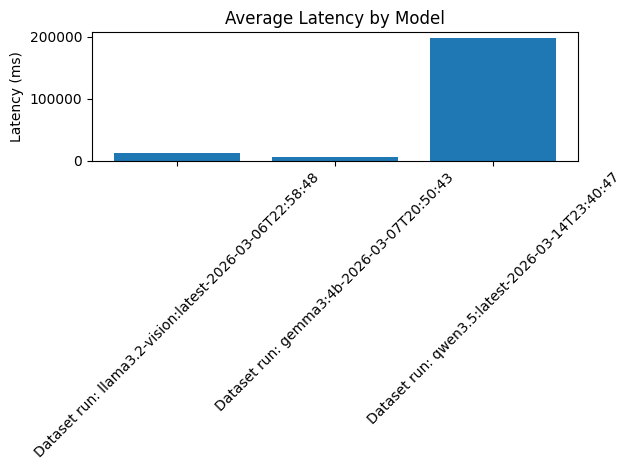

In [9]:
plt.figure()
plt.bar(summary['name'], summary['latency_ms'])
plt.title('Average Latency by Model')
plt.ylabel('Latency (ms)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

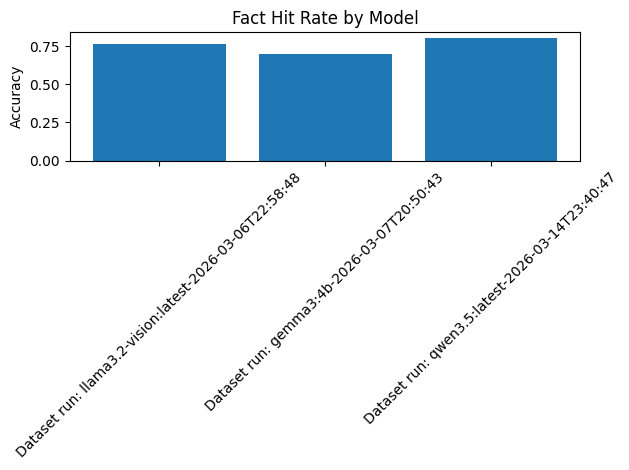

In [10]:
plt.figure()
plt.bar(summary['name'], summary['response_facts_hit_rate'])
plt.title('Fact Hit Rate by Model')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

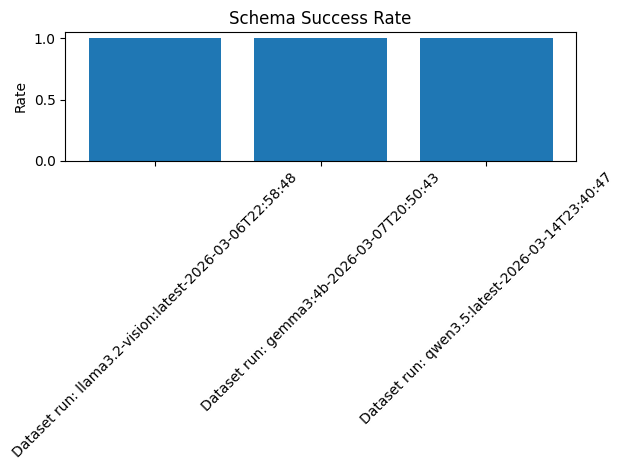

In [11]:
plt.figure()
plt.bar(summary['name'], summary['schema_ok'])
plt.title('Schema Success Rate')
plt.ylabel('Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

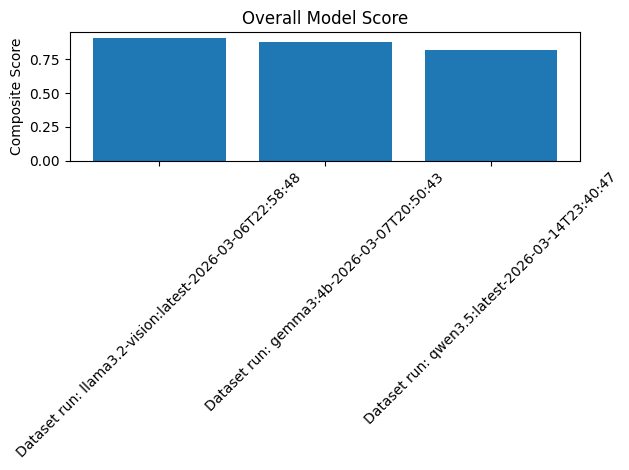

In [12]:
plt.figure()
plt.bar(summary['name'], summary['final_score'])
plt.title('Overall Model Score')
plt.ylabel('Composite Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

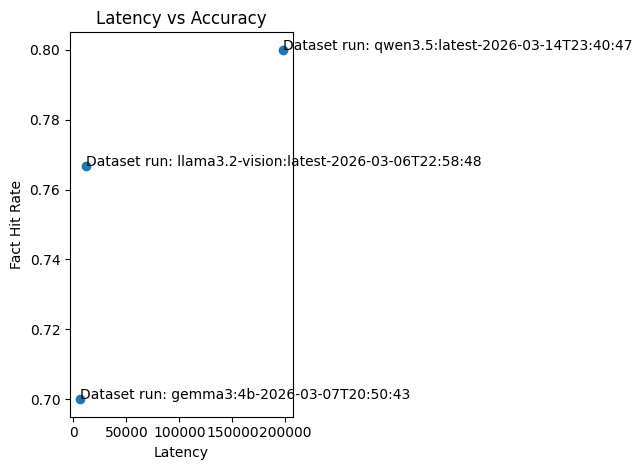

In [13]:
plt.figure()
plt.scatter(summary['latency_ms'], summary['response_facts_hit_rate'])

for i,row in summary.iterrows():
    plt.text(row['latency_ms'], row['response_facts_hit_rate'], row['name'])

plt.xlabel('Latency')
plt.ylabel('Fact Hit Rate')
plt.title('Latency vs Accuracy')
plt.tight_layout()
plt.show()